/var/folders/kb/jkhhkfp92jbgryf8vwdhfn7h0000gn/T/ipykernel_74446/1322112092.py:79: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file_path, delim_whitespace=True)
/var/folders/kb/jkhhkfp92jbgryf8vwdhfn7h0000gn/T/ipykernel_74446/1322112092.py:79: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file_path, delim_whitespace=True)
/var/folders/kb/jkhhkfp92jbgryf8vwdhfn7h0000gn/T/ipykernel_74446/1322112092.py:79: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file_path, delim_whitespace=True)
/var/folders/kb/jkhhkfp92jbgryf8vwdhfn7h0000gn/T/ipykernel_74446/1322112092.py:79: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will

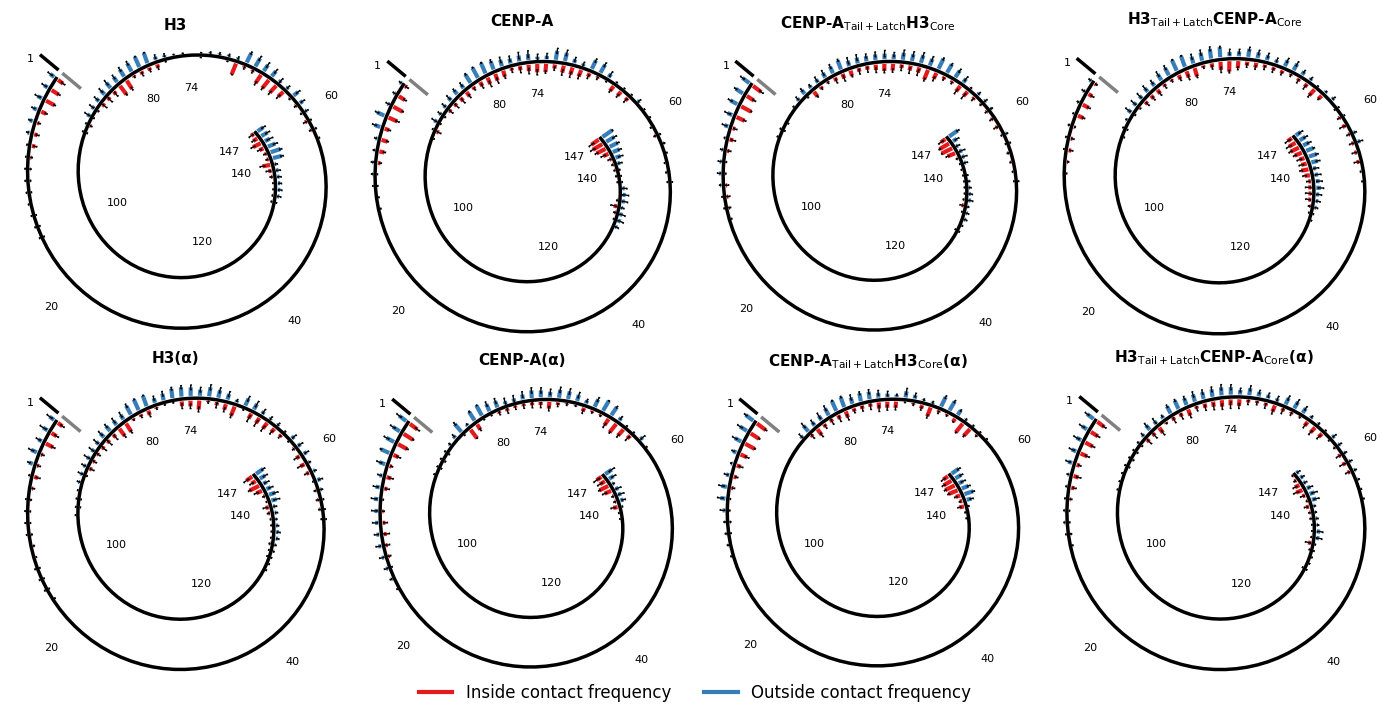

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

num_bp = 147

a, b = 0.5, 0.05
num_turns = 1.7
theta_total = num_turns * 2 * np.pi

MAX_BAR_LENGTH = 0.15
baseline_offset = 0.015

label_fs = 8
subtitle_fs = 11

colors_inside = "#E41A1C"
colors_outside = "#377EB8"
spiral_color = "black"

# -----------------------------
# Grid layout
# -----------------------------
grid_systems = [
    ["H3", "cenpa", "ltH3core", "ltcenpacore"],
    ["CSH3", "CScenpa", "CSltH3core", "CSltcenpacore"]

]

# -----------------------------
# Official titles
# -----------------------------
titles = {
    "H3": "H3",
    "cenpa": "CENP-A",
    "ltH3core": "CENP-A$_{\\mathrm{Tail+Latch}}$H3$_{\\mathrm{Core}}$",
    "ltcenpacore": "H3$_{\\mathrm{Tail+Latch}}$CENP-A$_{\\mathrm{Core}}$",
    "CSH3": "H3(\u03B1)",
    "CScenpa": "CENP-A(\u03B1)",
    "CSltH3core": "CENP-A$_{\\mathrm{Tail+Latch}}$H3$_{\\mathrm{Core}}$(\u03B1)",
    "CSltcenpacore": "H3$_{\\mathrm{Tail+Latch}}$CENP-A$_{\\mathrm{Core}}$(\u03B1)"
}

# -----------------------------
# Create figure
# -----------------------------
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.flatten()

# -----------------------------
# Precompute spiral
# -----------------------------
theta = np.linspace(theta_total, 0, num_bp)
r_center = a + b * theta
x_center = r_center * np.cos(theta)
y_center = -r_center * np.sin(theta)
angle_rot = np.deg2rad(35)
x_rot = x_center * np.cos(angle_rot) - y_center * np.sin(angle_rot)
y_rot = x_center * np.sin(angle_rot) + y_center * np.cos(angle_rot)
x_center, y_center = x_rot, y_rot

# -----------------------------
# Loop through grid
# -----------------------------
for idx, ax in enumerate(axes):

    r = idx // 4
    c = idx % 4
    system = grid_systems[r][c]

    # Blank panel
    if system is None:
        ax.axis("off")
        continue

    # Load data
    file_path = f"{system}/tail_contacts_inside_outside_freq_SEM.dat"
    df = pd.read_csv(file_path, delim_whitespace=True)

    inside_freq = np.zeros(num_bp)
    outside_freq = np.zeros(num_bp)
    inside_sem = np.zeros(num_bp)
    outside_sem = np.zeros(num_bp)

    for i in range(num_bp):
        base_A = i + 1
        base_B = 295 - base_A
        row_A = df[df["DNA_Base"] == base_A].iloc[0]
        row_B = df[df["DNA_Base"] == base_B].iloc[0]

        # Average mean and combined SEM for the base pair
        inside_freq[i] = (row_A["Inside_Mean"] + row_B["Inside_Mean"]) / 2
        outside_freq[i] = (row_A["Outside_Mean"] + row_B["Outside_Mean"]) / 2

        inside_sem[i] = np.sqrt(row_A["Inside_SEM"]**2 + row_B["Inside_SEM"]**2) / 2
        outside_sem[i] = np.sqrt(row_A["Outside_SEM"]**2 + row_B["Outside_SEM"]**2) / 2

    # -----------------------------
    # Plot spiral backbone
    # -----------------------------
    ax.plot(x_center, y_center, color=spiral_color, lw=2.5, zorder=20)

    # -----------------------------
    # Plot reference bars at "bp 0"
    # -----------------------------
    # Vector along spiral start, extrapolated for "bp 0"
    dx0, dy0 = x_center[1] - x_center[0], y_center[1] - y_center[0]
    tangent0 = np.array([dx0, dy0])
    tangent0 /= np.linalg.norm(tangent0)

    # Move slightly backward along tangent for bp0
    shift = 0.05
    x0 = x_center[0] - tangent0[0]*shift
    y0 = y_center[0] - tangent0[1]*shift
    vec_unit0 = np.array([x0, y0]) / np.linalg.norm([x0, y0])

    # Outside black ref bar
    ref_out_start_x = x0 + vec_unit0[0]*baseline_offset
    ref_out_start_y = y0 + vec_unit0[1]*baseline_offset
    ref_out_end_x = ref_out_start_x + vec_unit0[0]*MAX_BAR_LENGTH
    ref_out_end_y = ref_out_start_y + vec_unit0[1]*MAX_BAR_LENGTH
    ax.plot([ref_out_start_x, ref_out_end_x],
            [ref_out_start_y, ref_out_end_y],
            color="black", lw=2.5, solid_capstyle='butt', zorder=25)

    # Inside gray ref bar
    ref_in_start_x = x0 - vec_unit0[0]*baseline_offset
    ref_in_start_y = y0 - vec_unit0[1]*baseline_offset
    ref_in_end_x = ref_in_start_x - vec_unit0[0]*MAX_BAR_LENGTH
    ref_in_end_y = ref_in_start_y - vec_unit0[1]*MAX_BAR_LENGTH
    ax.plot([ref_in_start_x, ref_in_end_x],
            [ref_in_start_y, ref_in_end_y],
            color="gray", lw=2.5, solid_capstyle='butt', zorder=24)

    # -----------------------------
    # Plot data bars and SEM
    # -----------------------------
    for i in range(num_bp):
        x, y = x_center[i], y_center[i]
        vec = np.array([x, y])
        vec_unit = vec / np.linalg.norm(vec)

        # Start positions (from spiral line)
        start_in_x = x - vec_unit[0] * baseline_offset
        start_in_y = y - vec_unit[1] * baseline_offset
        start_out_x = x + vec_unit[0] * baseline_offset
        start_out_y = y + vec_unit[1] * baseline_offset

        r_in = inside_freq[i] * MAX_BAR_LENGTH
        r_out = outside_freq[i] * MAX_BAR_LENGTH

        in_end_x = start_in_x - vec_unit[0] * r_in
        in_end_y = start_in_y - vec_unit[1] * r_in
        out_end_x = start_out_x + vec_unit[0] * r_out
        out_end_y = start_out_y + vec_unit[1] * r_out

        # Inside bar
        if inside_freq[i] > 0:
            ax.plot([start_in_x, in_end_x], [start_in_y, in_end_y],
                    color=colors_inside, lw=3, solid_capstyle='butt')
        # Outside bar
        if outside_freq[i] > 0:
            ax.plot([start_out_x, out_end_x], [start_out_y, out_end_y],
                    color=colors_outside, lw=3, solid_capstyle='butt')

        # SEM bars with T caps starting from tip of data bars
        cap_len = 0.003  # T cap half-width

        # Inside SEM
        if inside_freq[i] > 0:
            tip_x, tip_y = in_end_x, in_end_y
            err_in = inside_sem[i] * MAX_BAR_LENGTH
            ax.plot([tip_x - vec_unit[0]*err_in, tip_x + vec_unit[0]*err_in],
                    [tip_y - vec_unit[1]*err_in, tip_y + vec_unit[1]*err_in],
                    color="black", lw=1, solid_capstyle='butt')
            ax.plot([tip_x - vec_unit[0]*err_in, tip_x - vec_unit[0]*err_in + vec_unit[1]*cap_len],
                    [tip_y - vec_unit[1]*err_in, tip_y - vec_unit[1]*err_in - vec_unit[0]*cap_len],
                    color="black", lw=1)
            ax.plot([tip_x + vec_unit[0]*err_in, tip_x + vec_unit[0]*err_in + vec_unit[1]*cap_len],
                    [tip_y + vec_unit[1]*err_in, tip_y + vec_unit[1]*err_in - vec_unit[0]*cap_len],
                    color="black", lw=1)

        # Outside SEM
        if outside_freq[i] > 0:
            tip_x, tip_y = out_end_x, out_end_y
            err_out = outside_sem[i] * MAX_BAR_LENGTH
            ax.plot([tip_x - vec_unit[0]*err_out, tip_x + vec_unit[0]*err_out],
                    [tip_y - vec_unit[1]*err_out, tip_y + vec_unit[1]*err_out],
                    color="black", lw=1, solid_capstyle='butt')
            ax.plot([tip_x - vec_unit[0]*err_out, tip_x - vec_unit[0]*err_out + vec_unit[1]*cap_len],
                    [tip_y - vec_unit[1]*err_out, tip_y - vec_unit[1]*err_out - vec_unit[0]*cap_len],
                    color="black", lw=1)
            ax.plot([tip_x + vec_unit[0]*err_out, tip_x + vec_unit[0]*err_out + vec_unit[1]*cap_len],
                    [tip_y + vec_unit[1]*err_out, tip_y + vec_unit[1]*err_out - vec_unit[0]*cap_len],
                    color="black", lw=1)

    # Base pair labels
    for i in range(num_bp):
        if (i+1) % 20 == 0 or (i+1) == 1 or (i+1) == 74 or (i+1) == 147:
            x, y = x_center[i], y_center[i]
            vec = np.array([x, y])
            vec_unit = vec / np.linalg.norm(vec)
            # place labels outside max data bar length
            label_offset = MAX_BAR_LENGTH + 0.05
            if i >= 73:  # inside spiral for bases 74+
                label_offset *= -1
            label_x = x + vec_unit[0]*label_offset
            label_y = y + vec_unit[1]*label_offset
            ax.text(label_x, label_y, str(i+1), fontsize=label_fs, ha="center", va="center")

    ax.set_title(titles[system], fontsize=subtitle_fs, fontweight="bold")
    ax.set_aspect("equal")
    ax.axis("off")

# After the loop over axes and plotting everything
fig.legend(
    handles=[
        Line2D([0], [0], color=colors_inside, lw=3, label="Inside contact frequency"),
        Line2D([0], [0], color=colors_outside, lw=3, label="Outside contact frequency")
    ],
    loc='lower center',   # places legend at bottom center of figure
    ncol=2,               # two columns in the legend
    fontsize=12,
    frameon=False,
    bbox_to_anchor=(0.5, -0.02)  # adjust vertical position below subplots
)
    
plt.tight_layout()
plt.savefig("spiral_contacts_AA_allsystems.pdf", dpi=300)
plt.savefig("spiral_contacts_AA_allsystems.png", dpi=300)
plt.show()